<a href="https://colab.research.google.com/github/sravaniommi/Credit-Card-Fraud-Detection/blob/main/Credit_card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

Upload the dataset


In [ ]:
credit_card_data = pd.read_csv('creditcard.csv')

View the first 5 rows


In [ ]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


View the last 5 rows

In [ ]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


Check dataset information

In [ ]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Check the size of the dataset

In [ ]:
credit_card_data.shape

(284807, 31)

Check missing values

In [ ]:
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Statistical information

In [ ]:
credit_card_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Check legitimate and fraudulent transactions

In [ ]:
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


Visualize the imbalance

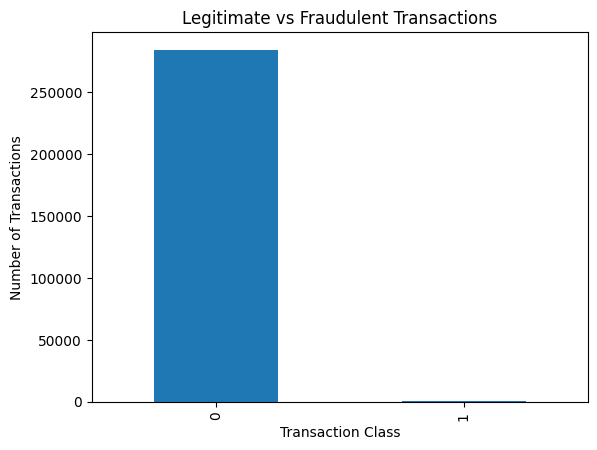

In [ ]:
credit_card_data['Class'].value_counts().plot(kind='bar')

plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.title('Legitimate vs Fraudulent Transactions')

plt.show()

Separate legitimate and fraudulent transactions

In [ ]:
legit = credit_card_data[
    credit_card_data.Class == 0
]

fraud = credit_card_data[
    credit_card_data.Class == 1
]

In [ ]:
print("Legitimate transactions:", legit.shape)
print("Fraudulent transactions:", fraud.shape)

Legitimate transactions: (284315, 31)
Fraudulent transactions: (492, 31)


Compare transaction amounts

In [ ]:
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [ ]:
fraud.Amount.describe()


,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
credit_card_data.groupby('Class')['Amount'].mean()

,Amount
Class,
0,88.291022
1,122.211321


Create a balanced dataset using under-sampling

In [ ]:
legit_sample = legit.sample(
    n=492,
    random_state=42
)

In [ ]:
print(legit_sample.shape)
print(fraud.shape)

(492, 31)
(492, 31)


Combine the two datasets

In [ ]:
new_dataset = pd.concat(
    [legit_sample, fraud],
    axis=0
)

In [ ]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
138028,82450.0,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,0.76,0
63099,50554.0,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,4.18,0
73411,55125.0,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,15.00,0
164247,116572.0,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,57.00,0
148999,90434.0,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,0.00,0


In [ ]:
new_dataset['Class'].value_counts()

,count
Class,
0,492
1,492


Separate features and target

In [ ]:
X = new_dataset.drop(
    columns='Class',
    axis=1
)

Y = new_dataset['Class']

Split data into training and testing

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000
)

In [ ]:
logistic_model.fit(
    X_train_scaled,
    Y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
logistic_prediction = logistic_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


**Evaluate Logistic Regression**
1.Accuracy

In [ ]:
logistic_accuracy = accuracy_score(
    Y_test,
    logistic_prediction
)

print(
    "Logistic Regression Accuracy:",
    logistic_accuracy
)

Logistic Regression Accuracy: 0.5025380710659898


2.Precision

In [ ]:
logistic_precision = precision_score(
    Y_test,
    logistic_prediction
)

print(
    "Logistic Regression Precision:",
    logistic_precision
)

Logistic Regression Precision: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


3.Recall

In [ ]:
logistic_recall = recall_score(
    Y_test,
    logistic_prediction
)

print(
    "Logistic Regression Recall:",
    logistic_recall
)

Logistic Regression Recall: 0.0


4.F1 Score

In [ ]:
logistic_f1 = f1_score(
    Y_test,
    logistic_prediction
)

print(
    "Logistic Regression F1 Score:",
    logistic_f1
)

Logistic Regression F1 Score: 0.0


Logistic Regression classification report

In [ ]:
print(
    classification_report(
        Y_test,
        logistic_prediction
    )
)

              precision    recall  f1-score   support

           0       0.50      1.00      0.67        99
           1       0.00      0.00      0.00        98

    accuracy                           0.50       197
   macro avg       0.25      0.50      0.33       197
weighted avg       0.25      0.50      0.34       197



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression confusion matrix

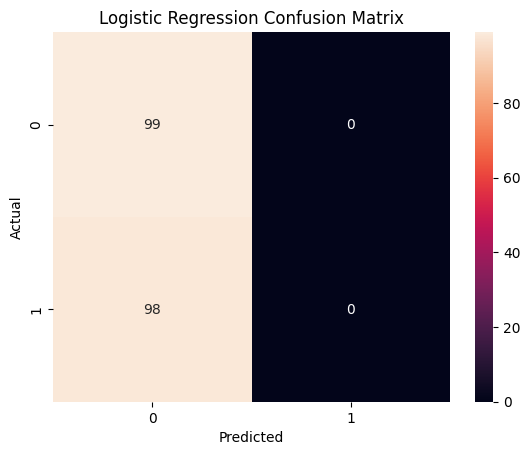

In [ ]:
logistic_cm = confusion_matrix(
    Y_test,
    logistic_prediction
)

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_forest_model.fit(
    X_train,
    Y_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
random_forest_prediction = (
    random_forest_model.predict(X_test)
)

**Evaluate Random Forest**

Accuracy

In [ ]:
random_forest_accuracy = accuracy_score(
    Y_test,
    random_forest_prediction
)

print(
    "Random Forest Accuracy:",
    random_forest_accuracy
)

Random Forest Accuracy: 0.9543147208121827


Precision

In [ ]:
random_forest_precision = precision_score(
    Y_test,
    random_forest_prediction
)

print(
    "Random Forest Precision:",
    random_forest_precision
)

Random Forest Precision: 0.968421052631579


Recall

In [ ]:
random_forest_recall = recall_score(
    Y_test,
    random_forest_prediction
)

print(
    "Random Forest Recall:",
    random_forest_recall
)

Random Forest Recall: 0.9387755102040817


F1 Score

In [ ]:
random_forest_f1 = f1_score(
    Y_test,
    random_forest_prediction
)

print(
    "Random Forest F1 Score:",
    random_forest_f1
)

Random Forest F1 Score: 0.9533678756476683


Random Forest classification report

In [ ]:
print(
    classification_report(
        Y_test,
        random_forest_prediction
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96        99
           1       0.97      0.94      0.95        98

    accuracy                           0.95       197
   macro avg       0.95      0.95      0.95       197
weighted avg       0.95      0.95      0.95       197



Random Forest confusion matrix

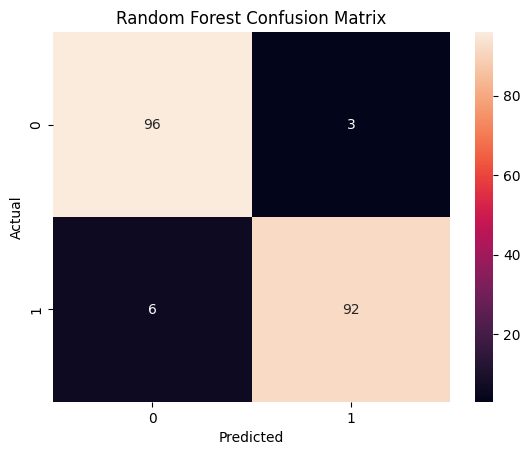

In [ ]:
random_forest_cm = confusion_matrix(
    Y_test,
    random_forest_prediction
)

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')

plt.show()

Compare both models

In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        logistic_accuracy,
        random_forest_accuracy
    ],

    'Precision': [
        logistic_precision,
        random_forest_precision
    ],

    'Recall': [
        logistic_recall,
        random_forest_recall
    ],

    'F1 Score': [
        logistic_f1,
        random_forest_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.502538,0.000000,0.000000,0.000000
1,Random Forest,0.954315,0.968421,0.938776,0.953368


ROC-AUC comparison

In [ ]:
logistic_probability = (
    logistic_model.predict_proba(X_test)[:, 1]
)

random_forest_probability = (
    random_forest_model.predict_proba(X_test)[:, 1]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
logistic_roc_auc = roc_auc_score(
    Y_test,
    logistic_probability
)

random_forest_roc_auc = roc_auc_score(
    Y_test,
    random_forest_probability
)

print(
    "Logistic Regression ROC-AUC:",
    logistic_roc_auc
)

print(
    "Random Forest ROC-AUC:",
    random_forest_roc_auc
)

Logistic Regression ROC-AUC: 0.4898989898989899
Random Forest ROC-AUC: 0.9901051329622758


Final model comparison

In [ ]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        logistic_accuracy,
        random_forest_accuracy
    ],

    'Precision': [
        logistic_precision,
        random_forest_precision
    ],

    'Recall': [
        logistic_recall,
        random_forest_recall
    ],

    'F1 Score': [
        logistic_f1,
        random_forest_f1
    ],

    'ROC-AUC': [
        logistic_roc_auc,
        random_forest_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.502538,0.000000,0.000000,0.000000,0.489899
1,Random Forest,0.954315,0.968421,0.938776,0.953368,0.990105
